**First save a copy of this notebook in your Google drive.** Read this notebook from top to bottom and fill in the code as you go. Work together with your partner and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas.





## Titanic Data

 The Titanic data set (https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv) contains information about 2206 passengers and crew members that were aboard the RMS Titanic when it sank on April 15, 1912.

1\. Read in the Titanic data set. What seems to be the observational unit?

In [ ]:
import pandas as pd

titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")

In [ ]:
titanic.head()

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN


Answer: Each row represents one passenger or crew member on the Titanic.

2\. What column seems to be an appropriate index for this data frame? Can you think of any problems with using this column as the index?

In [ ]:
titanic["name"].is_unique

False

Answer: The name column could be the index, but some names are repeated.

3\. Regardless of your answer to the previous question, write code to make "name" the index of the data frame.

In [ ]:
titanic = titanic.set_index("name")

 4\. Write code that returns the observations for  "Kelly, Mr. James". What do you notice? (You can also try "Green, Mr. George"). Note: you might try this both with "name" as the index and with it not as the index.

In [ ]:
titanic.loc["Kelly, Mr. James"]

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
name,,,,,,,,,,
"Kelly, Mr. James",male,19.0,3rd,S,Scotland,363592.0,8.0100,0,3.0,NaN
"Kelly, Mr. James",male,44.0,3rd,Q,Ireland,330911.0,7.1607,0,3.0,NaN
"Kelly, Mr. James",male,44.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew


Answer: Three people have the same name, so the name index is not unique.

5\. Write code to extract a single `DataFrame` containing the observations three members of the Widener family:
  - Widener, Mr. George Dunton
  - Widener, Mr. Harry Elkins
  - Widener, Mrs. Eleanor

What became of them? Using a search engine, what else can you learn about them? (Note: you could just provide a list of these names. But you might also want to experiment with functions for working with strings, e.g., [`str.contains`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html) to find all instances of "Widener"; in this case, it might be helpful to have name as a regular column and not the index.)

In [ ]:
widener_names = [
    "Widener, Mr. George Dunton",
    "Widener, Mr. Harry Elkins",
    "Widener, Mrs. Eleanor"
]

In [ ]:
titanic.loc[widener_names]

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
name,,,,,,,,,,
"Widener, Mr. George Dunton",male,50.0,1st,S,United States,113503.0,211.1,0,1.0,NaN
"Widener, Mr. Harry Elkins",male,27.0,1st,S,United States,113503.0,211.1,0,1.0,NaN
"Widener, Mrs. Eleanor",female,50.0,1st,S,United States,113503.0,211.1,1,1.0,NaN


Answer: George and Harry did not survive, but Eleanor did. Eleanor later helped build Widener Library at Harvard in memory of Harry.

6\. Look at a few rows in the full data set. Try to identify what each variable measures. Also, try to identify each variable as either quantitative, categorical, or other. (In general, there should be a code book with information about all the variables. But try to infer what you can from context.)

In [ ]:
titanic.reset_index().head(10)

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.1100,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.0500,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.0500,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.0500,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.1300,1,3.0,NaN
5,"Abelseth, Mr. Olaus Jørgensen",male,25.0,3rd,S,United States,348122.0,7.1300,1,3.0,NaN
6,"Abelson, Mr. Samuel",male,30.0,2nd,C,France,3381.0,24.0000,0,2.0,NaN
7,"Abelson, Mrs. Hannah",female,28.0,2nd,C,France,3381.0,24.0000,1,2.0,NaN
8,"Abī-Al-Munà, Mr. Nāsīf Qāsim",male,27.0,3rd,C,Lebanon,2699.0,18.1509,1,3.0,NaN
9,"Abrahamsson, Mr. Abraham August Johannes",male,20.0,3rd,S,Finland,3101284.0,7.1806,1,3.0,NaN


Answer: name: person’s name is other, gender: male or female is categorical,  age: person’s age is quantitative, class: travel class is categorical, embarked: boarding location is categorical, country: home country is categorical, ticketno: ticket number is other, fare: ticket price is quantitative, survived: whether the person survived is categorical, pclass: passenger class is categorical, crew: crew type is categorical.

7\. The variable `pclass` measures the class for passengers. Why are some of the values in this column `NaN`? Should this variable be categorical or quantitative? What type does Pandas this it is?

In [ ]:
titanic["pclass"].dtype

dtype('float64')

Answer: Some values are NaN because crew members do not have a passenger class.
This variable should be categorical, but Pandas lists it as float64.

8\. Write code to cast `pclass` to the correct type. Repeat for any other variables that do not have the correct type.

In [ ]:
titanic["pclass"] = titanic["pclass"].astype("category")

In [ ]:
titanic["pclass"].dtype

CategoricalDtype(categories=[1.0, 2.0, 3.0], ordered=False, categories_dtype=float64)

In [ ]:
titanic.dtypes

,0
gender,object
age,float64
class,object
embarked,object
country,object
ticketno,float64
fare,float64
survived,int64
pclass,category
crew,object


In [ ]:
titanic["gender"] = titanic["gender"].astype("category")

In [ ]:
titanic["class"] = titanic["class"].astype("category")

In [ ]:
titanic["embarked"] = titanic["embarked"].astype("category")

In [ ]:
titanic["country"] = titanic["country"].astype("category")

In [ ]:
titanic["survived"] = titanic["survived"].astype("category")

In [ ]:
titanic["crew"] = titanic["crew"].astype("category")

In [ ]:
titanic["ticketno"] = titanic["ticketno"].astype("string")

In [ ]:
titanic.dtypes

,0
gender,category
age,float64
class,category
embarked,category
country,category
ticketno,string[python]
fare,float64
survived,category
pclass,category
crew,category


## Transforming Categorical Variables

A categorical variable can be transformed by mapping its levels to new levels. For example, we may only be interested in whether a person on the titanic was a passenger or a crew member. The variable `class` is too detailed for these purposes. We can create a new variable, `type`, that is derived from the existing variable `class`. Observations with a `class` of "1st", "2nd", or "3rd" get a value of "passenger", while observations with a `class` of "deck crew", "engineering crew", or "deck crew" get a value of "crew".

In [ ]:
titanic["type"] = titanic["class"].map({
    "1st": "passenger",
    "2nd": "passenger",
    "3rd": "passenger",
    "victualling crew": "crew",
    "engineering crew": "crew",
    "deck crew": "crew"
})

titanic

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type
name,,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN,passenger
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN,passenger
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN,passenger
...,...,...,...,...,...,...,...,...,...,...,...
"Wynn, Mr. Walter",male,41.0,deck crew,B,England,<NA>,NaN,1,NaN,deck crew,crew
"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,<NA>,NaN,1,NaN,victualling crew,crew
"Young, Mr. Francis James",male,32.0,engineering crew,S,England,<NA>,NaN,0,NaN,engineering crew,crew


Upon closer inspection of this `DataFrame`, we see that we accidentally left out the level "restaurant staff" in the input to `.map()`. Any levels that are unspecified will be mapped to the missing value `NaN`.

This suggests a more concise way to define the new variable `type`. We can specify only the levels for passengers in the mapping and then fill in the missing values afterwards.

In [ ]:
titanic["type"] = titanic["class"].map({
    "1st": "passenger",
    "2nd": "passenger",
    "3rd": "passenger"
})

# Replace all missing values with "crew"
titanic["type"] = titanic["type"].fillna("crew")

titanic

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type
name,,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN,passenger
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN,passenger
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN,passenger
...,...,...,...,...,...,...,...,...,...,...,...
"Wynn, Mr. Walter",male,41.0,deck crew,B,England,<NA>,NaN,1,NaN,deck crew,crew
"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,<NA>,NaN,1,NaN,victualling crew,crew
"Young, Mr. Francis James",male,32.0,engineering crew,S,England,<NA>,NaN,0,NaN,engineering crew,crew


For more complex mappings, the `.map()` method also accepts a function. So the above is equivalent to

In [ ]:
def class_to_type(c):
    if c in ["1st", "2nd", "3rd"]:
        return "passenger"
    else:
        return "crew"

titanic["class"].map(class_to_type)

,class
name,
"Abbing, Mr. Anthony",passenger
"Abbott, Mr. Eugene Joseph",passenger
"Abbott, Mr. Rossmore Edward",passenger
"Abbott, Mrs. Rhoda Mary 'Rosa'",passenger
"Abelseth, Miss. Karen Marie",passenger
...,...
"Wynn, Mr. Walter",crew
"Yearsley, Mr. Harry",crew
"Young, Mr. Francis James",crew


## Converting Quantitative Variables to Categorical Variables

Sometimes it is necessary to categorize quantitative variables. We can use the `cut` function in `pandas` to categorize or bin a quantitative variable, by specifying the endpoints of the bins. We can also provide labels for the bins.

In [ ]:
titanic["age_categories"] = pd.cut(
    x=titanic["age"],
    bins=[0, 18, 30, 45, 65, 130],
    labels=["<18", "18-30", "30-45", "45-65", "65+"]
)

titanic

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type,age_categories
name,,,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN,passenger,30-45
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger,<18
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger,<18
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN,passenger,30-45
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN,passenger,<18
...,...,...,...,...,...,...,...,...,...,...,...,...
"Wynn, Mr. Walter",male,41.0,deck crew,B,England,<NA>,NaN,1,NaN,deck crew,crew,30-45
"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,<NA>,NaN,1,NaN,victualling crew,crew,30-45
"Young, Mr. Francis James",male,32.0,engineering crew,S,England,<NA>,NaN,0,NaN,engineering crew,crew,30-45


Now we can treat the new variable as we would any other categorical variable.

In [ ]:
titanic["age_categories"]

,age_categories
name,
"Abbing, Mr. Anthony",30-45
"Abbott, Mr. Eugene Joseph",<18
"Abbott, Mr. Rossmore Edward",<18
"Abbott, Mrs. Rhoda Mary 'Rosa'",30-45
"Abelseth, Miss. Karen Marie",<18
...,...
"Wynn, Mr. Walter",30-45
"Yearsley, Mr. Harry",30-45
"Young, Mr. Francis James",30-45


Arguments to the `cut` method can be specified to determine the treatment of the bin endpoints, but we won't go into the details here. There is also a `qcut` method which creates bins based on quantiles (e.g., the endpoints are the 25th, 50th, and 75th percentiles (along with the min and max).)

## Back to the Exercises about the Titanic data...

10\. Create a new country column that contains only the values United States, United Kingdom, or Other. (At the time of the Titanic, the countries in the United Kingdom were England, Scotland, Wales, and Ireland, including what is now Northern Ireland.) Don't overwrite the original country column.

In [ ]:
def group_country(country):
    if country == "United States":
        return "United States"
    elif country in ["England", "Scotland", "Wales", "Ireland"]:
        return "United Kingdom"
    else:
        return "Other"

In [ ]:
titanic["country_group"] = titanic["country"].apply(group_country)

In [ ]:
titanic[["country", "country_group"]].head(10)

,country,country_group
name,,
"Abbing, Mr. Anthony",United States,United States
"Abbott, Mr. Eugene Joseph",United States,United States
"Abbott, Mr. Rossmore Edward",United States,United States
"Abbott, Mrs. Rhoda Mary 'Rosa'",England,United Kingdom
"Abelseth, Miss. Karen Marie",Norway,Other
"Abelseth, Mr. Olaus Jørgensen",United States,United States
"Abelson, Mr. Samuel",France,Other
"Abelson, Mrs. Hannah",France,Other
"Abī-Al-Munà, Mr. Nāsīf Qāsim",Lebanon,Other


11\. Create a new column that categorizes the fare variable into bins of length 5 from 0 to 25, bins of length 25 from 25 to 100, and 100+.

In [ ]:
titanic["fare_group"] = pd.cut(
    titanic["fare"],
    bins=[0, 5, 10, 15, 20, 25, 50, 75, 100, float("inf")],
    labels=["0-5", "5-10", "10-15", "15-20", "20-25",
            "25-50", "50-75", "75-100", "100+"],
    include_lowest=True
)

In [ ]:
titanic[["fare", "fare_group"]].head(10)

,fare,fare_group
name,,
"Abbing, Mr. Anthony",7.1100,5-10
"Abbott, Mr. Eugene Joseph",20.0500,20-25
"Abbott, Mr. Rossmore Edward",20.0500,20-25
"Abbott, Mrs. Rhoda Mary 'Rosa'",20.0500,20-25
"Abelseth, Miss. Karen Marie",7.1300,5-10
"Abelseth, Mr. Olaus Jørgensen",7.1300,5-10
"Abelson, Mr. Samuel",24.0000,20-25
"Abelson, Mrs. Hannah",24.0000,20-25
"Abī-Al-Munà, Mr. Nāsīf Qāsim",18.1509,15-20


## Working with Gemini

Colab notebooks have [Gemini](), Google's AI, built in. Let's try it.

1\. Load either the Titanic data frame. After you load the data frame, there should be a button for "View recommended plot". Turn that button on and see what you get. Select one of the suggested plots that summarizes a single categorical variable. (Careful: make sure it's a single categorical variable. Some of the bar plots might be summarizing multiple variables.) What are features that you like about the plot? Are there any features you don't like?

In [ ]:
titanic

,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type,age_categories,country_group,fare_group
name,,,,,,,,,,,,,,
"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN,passenger,30-45,United States,5-10
"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger,<18,United States,20-25
"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger,<18,United States,20-25
"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN,passenger,30-45,United Kingdom,20-25
"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN,passenger,<18,Other,5-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Wynn, Mr. Walter",male,41.0,deck crew,B,England,<NA>,NaN,1,NaN,deck crew,crew,30-45,United Kingdom,NaN
"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,<NA>,NaN,1,NaN,victualling crew,crew,30-45,United Kingdom,NaN
"Young, Mr. Francis James",male,32.0,engineering crew,S,England,<NA>,NaN,0,NaN,engineering crew,crew,30-45,United Kingdom,NaN


<Axes: xlabel='class'>

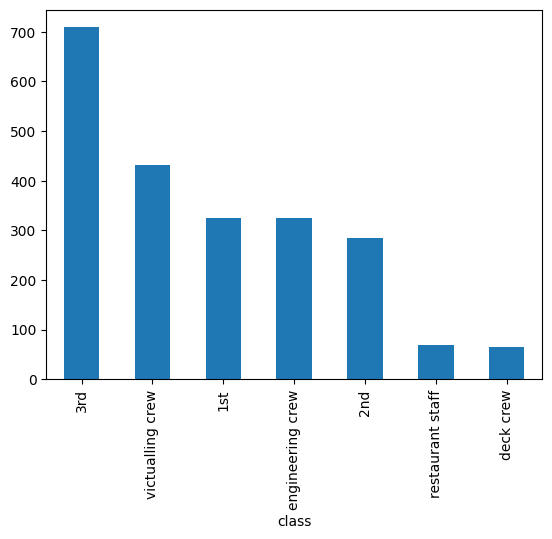

In [ ]:
titanic["class"].value_counts().plot(kind="bar")

Answer: I like that the bar chart makes it easy to compare the different classes. I can quickly see that 3rd class has the most people. I do not like that some class names are long and hard to read.

2\. Now click on the "generate" with AI link, or the Gemini button. Write a prompt to reproduce some of your analysis from earlier in this notebook. You can copy and paste one of the questions, or you can try writing your own prompt. Run the code and examine the results. How successful was it?

<Axes: xlabel='country_group'>

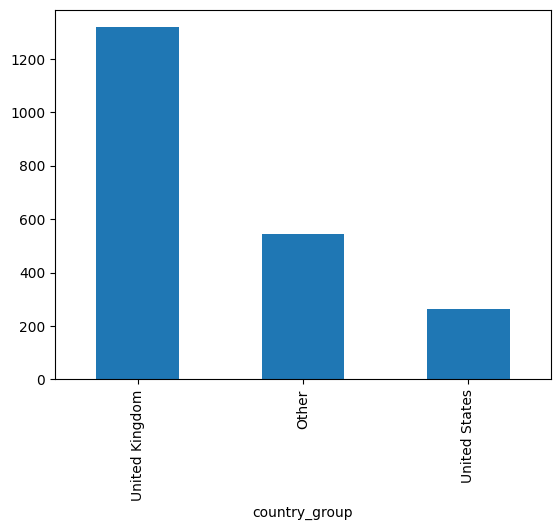

In [ ]:
titanic["country_group"].value_counts().plot(kind="bar")

Answer: It was successful. The code created a bar chart and showed the number of people in each country group.